In [1]:
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program.csv")

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,21-Dec-25,6,18,11,"2,484",14
1,18-Dec-25,11,50,6,"2,472",16
2,17-Dec-25,7,31,11,"2,481",10
3,16-Dec-25,8,54,15,"2,468",9
4,15-Dec-25,11,42,9,"2,470",7


In [4]:
print(df.columns)

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')

df.set_index('Date', inplace=True)

df.head()

/tmp/ipython-input-411/2246194512.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33,53,34,"6,566",436
2023-01-22,32,49,39,"7,122",227
2023-01-23,32,50,39,"7,280",181
2023-01-24,47,42,47,"7,433",175
2023-01-25,20,22,41,"7,538",180


In [7]:
df.isnull().sum()

,0
Children apprehended and placed in CBP custody*,0
Children in CBP custody,0
Children transferred out of CBP custody,0
Children in HHS Care,0
Children discharged from HHS Care,0


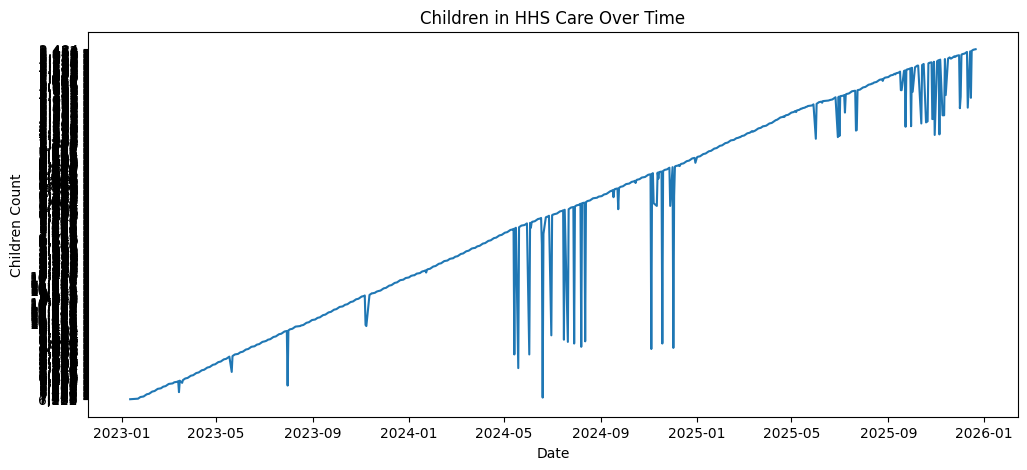

In [8]:
plt.figure(figsize=(12,5))
plt.plot(df['Children in HHS Care'])
plt.title("Children in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Children Count")
plt.show()

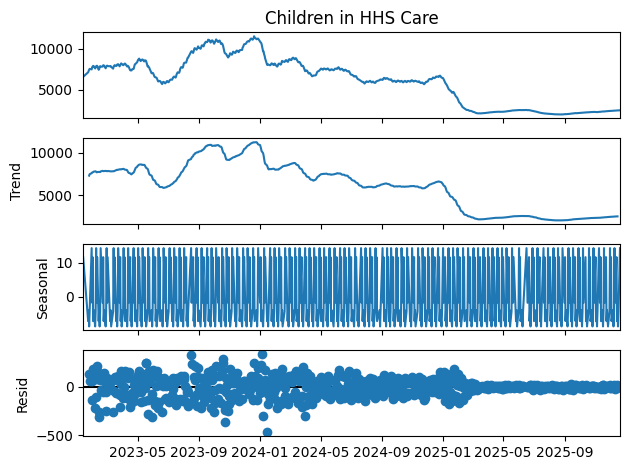

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd

# Convert 'Children in HHS Care' to numeric by removing commas if it's not already numeric
if pd.api.types.is_string_dtype(df['Children in HHS Care']): # Check if the column is of string type
    df['Children in HHS Care'] = df['Children in HHS Care'].str.replace(',', '').astype(float)

decomposition = seasonal_decompose(df['Children in HHS Care'],model='additive',period=7)

decomposition.plot()
plt.show()

In [13]:
df['lag_1'] = df['Children in HHS Care'].shift(1)
df['lag_7'] = df['Children in HHS Care'].shift(7)
df['lag_14'] = df['Children in HHS Care'].shift(14)

In [15]:
df['rolling_7'] = df['Children in HHS Care'].rolling(7).mean()
df['rolling_14'] = df['Children in HHS Care'].rolling(14).mean()

In [16]:
df['Net_Pressure'] = (
    df['Children transferred out of CBP custody']
    - df['Children discharged from HHS Care'])

In [17]:
df.dropna(inplace=True)

In [18]:
df.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,lag_1,lag_7,lag_14,rolling_7,rolling_14,Net_Pressure
Date,,,,,,,,,,,
2023-02-09,124,234,161,7908.0,353,7915.0,7803.0,6566.0,7823.714286,7654.071429,-192
2023-02-12,92,203,173,7434.0,317,7908.0,7903.0,7122.0,7756.714286,7676.357143,-144
2023-02-13,186,259,172,7483.0,244,7434.0,7879.0,7280.0,7700.142857,7690.857143,-72
2023-02-14,154,225,220,7794.0,223,7483.0,7586.0,7433.0,7729.857143,7716.642857,-3
2023-02-15,91,199,172,7869.0,290,7794.0,7720.0,7538.0,7751.142857,7740.285714,-118


In [19]:
train = df.iloc[:-30]
test = df.iloc[-30:]

In [20]:
test['Naive_Forecast'] = train['Children in HHS Care'].iloc[-1]

/tmp/ipython-input-411/724295430.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Naive_Forecast'] = train['Children in HHS Care'].iloc[-1]


In [21]:
from statsmodels.tsa.arima.model import ARIMA

In [22]:
model = ARIMA(train['Children in HHS Care'],order=(5,1,0))

model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [23]:
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


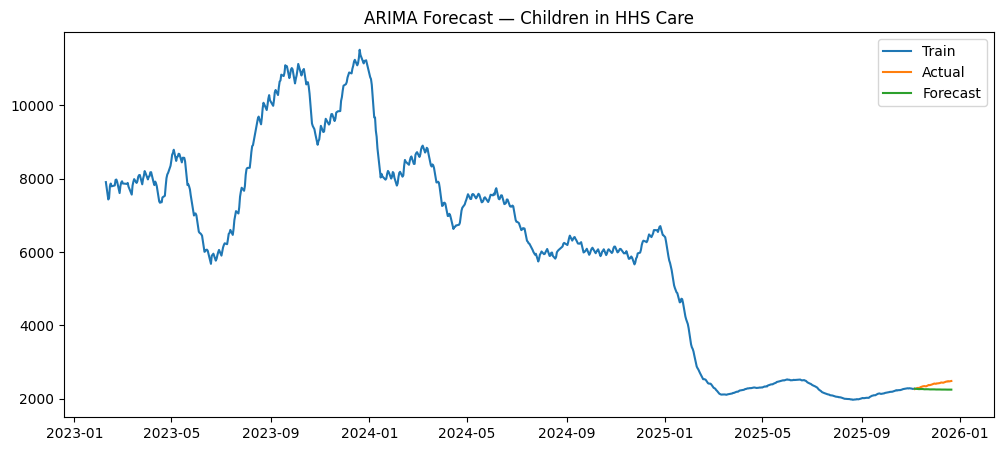

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(train.index, train['Children in HHS Care'])
plt.plot(test.index, test['Children in HHS Care'])
plt.plot(test.index, forecast)

plt.legend(['Train','Actual','Forecast'])
plt.title("ARIMA Forecast — Children in HHS Care")

plt.show()

In [25]:
X = df.drop('Children in HHS Care', axis=1)
y = df['Children in HHS Care']

In [26]:
X_train = X.iloc[:-30]
X_test = X.iloc[-30:]

y_train = y.iloc[:-30]
y_test = y.iloc[-30:]

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

MAE: 13.429666666666662
RMSE: 17.242958079556193


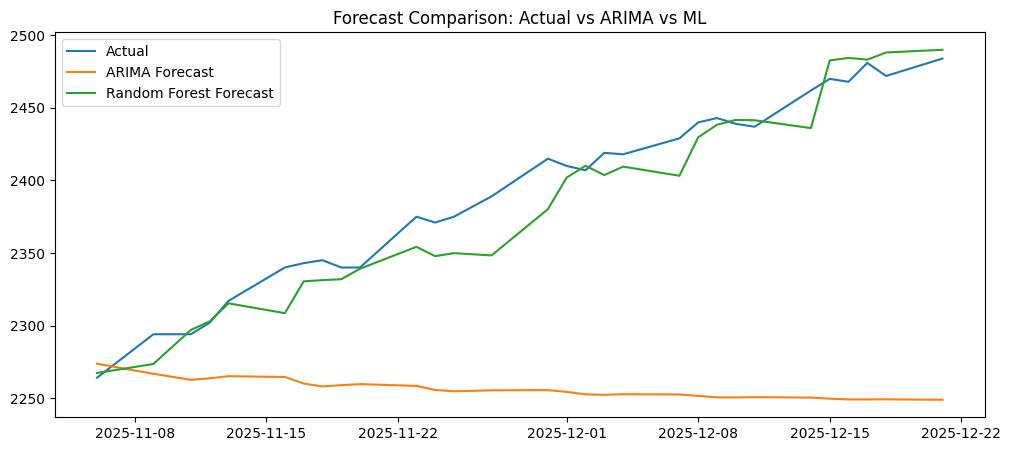

In [29]:
plt.figure(figsize=(12,5))

plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, forecast, label="ARIMA Forecast")
plt.plot(y_test.index, rf_pred, label="Random Forest Forecast")

plt.title("Forecast Comparison: Actual vs ARIMA vs ML")
plt.legend()

plt.show()

In [31]:
importance = rf.feature_importances_

features = X.columns

importance_df = pd.DataFrame({'Feature': features,'Importance': importance}).sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
4,lag_1,0.599342
7,rolling_7,0.376119
8,rolling_14,0.017713
6,lag_14,0.003051
5,lag_7,0.002352
9,Net_Pressure,0.000362
3,Children discharged from HHS Care,0.000303
0,Children apprehended and placed in CBP custody*,0.000289
2,Children transferred out of CBP custody,0.000270
1,Children in CBP custody,0.000199


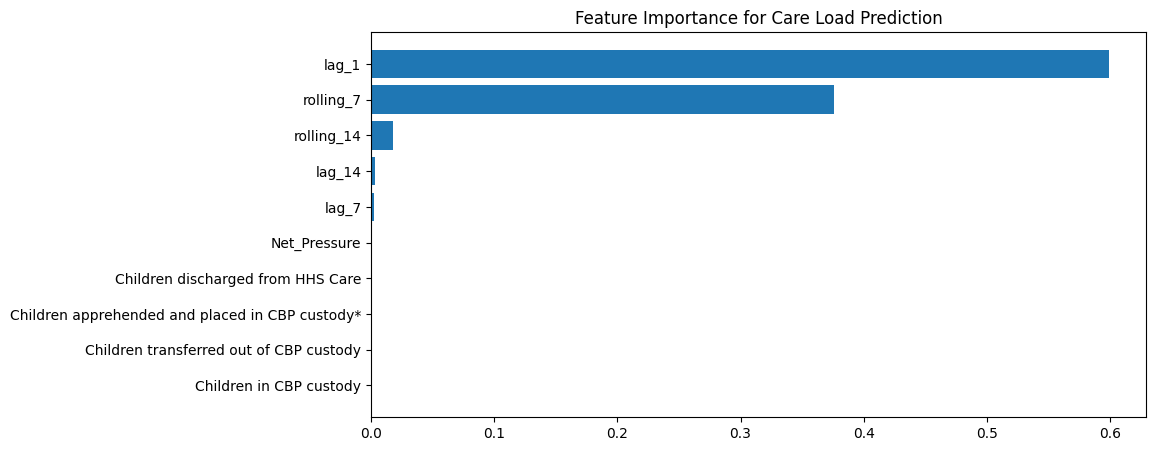

In [32]:
plt.figure(figsize=(10,5))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.title("Feature Importance for Care Load Prediction")
plt.gca().invert_yaxis()

plt.show()

In [33]:
df['Capacity_Risk'] = (
    df['Net_Pressure'] > df['Net_Pressure'].mean()
).astype(int)

In [34]:
avg_load = df['Children in HHS Care'].mean()
max_load = df['Children in HHS Care'].max()

print("Average Care Load:", avg_load)
print("Peak Care Load:", max_load)

Average Care Load: 6031.590651558074
Peak Care Load: 11516.0


In [35]:
df.to_csv("forecast_output.csv")

In [36]:
from google.colab import files
files.download("forecast_output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>